<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/Combined_Spat_Oxygen_Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Loading & Standardization (Respiration)
This block pulls the oxygen consumption rates from all four files, cleans the morph labels (HF vs NF), and maps the experimental treatments.

In [17]:
import pandas as pd
import numpy as np

# --- HELPER FUNCTION ---
def clean_morph(val):
    val = str(val).strip().upper()
    if 'HF' in val or 'HIGH' in val: return 'HF'
    if 'NF' in val or 'NO' in val: return 'NF'
    return None

# 1. Load Files (Corrected filenames based on content)
df_amb = pd.read_csv('Ambient_Assay.csv')
df_ph = pd.read_csv('pH_Assay.csv')
df_temp = pd.read_csv('Temp_Assay.csv')
df_light = pd.read_csv('Light_Assay.csv')

# 2. Map Treatments and Clean Morphs (Updated to use 'morph' column)
# Ambient
df_amb['morph_clean'] = df_amb['morph'].apply(clean_morph)
df_amb['Treatment'] = 'Ambient \n(23\u00b0C, pH 8.2, 10m)'

# pH
df_ph['morph_clean'] = df_ph['morph'].apply(clean_morph)
df_ph = df_ph[df_ph['pH'].isin([7.6, 7.8])].copy()
df_ph['Treatment'] = df_ph['pH'].apply(lambda x: f"pH {x}")

# Temp
df_temp['morph_clean'] = df_temp['morph'].apply(clean_morph)
df_temp = df_temp[df_temp['temp'].isin([27, 32])].copy()
df_temp['Treatment'] = df_temp['temp'].apply(lambda x: f"{x}\u00b0C")

# Light
df_light['morph_clean'] = df_light['morph'].apply(clean_morph)
df_light = df_light[df_light['LightDepth'].str.lower().isin(['50m', 'dark'])].copy()
df_light['Treatment'] = df_light['LightDepth'].str.capitalize()

# 3. Combine into Master Respiration DataFrame
cols_to_take = ['SampleCode', 'morph_clean', 'OxyRate nmol/mm2/min', 'Treatment']
master_respiration = pd.concat([df_amb[cols_to_take], df_ph[cols_to_take], df_temp[cols_to_take], df_light[cols_to_take]])

# Cleanup column names
master_respiration = master_respiration.rename(columns={'morph_clean': 'morph', 'OxyRate nmol/mm2/min': 'oxy_rate'})

# Drop PF and missing values
master_respiration = master_respiration[master_respiration['morph'].isin(['HF', 'NF'])].dropna()

print("Block 1 Complete: Master Respiration Data Merged.")

Block 1 Complete: Master Respiration Data Merged.


# Block 2: Outlier Removal & "Removed Samples" List

This block will not only clean the data using the $1.5 \times \text{IQR}$ rule but will also print the specific IDs and treatments of the samples that were removed.

In [18]:
# ==========================================
# BLOCK 2: OUTLIER REMOVAL & LOGGING
# ==========================================

master_respiration['is_outlier'] = False

for names, group in master_respiration.groupby(['morph', 'Treatment']):
    q1 = group['oxy_rate'].quantile(0.25)
    q3 = group['oxy_rate'].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    # Identify indices of outliers for this group
    indices = group[(group['oxy_rate'] < lower) | (group['oxy_rate'] > upper)].index
    master_respiration.loc[indices, 'is_outlier'] = True

# 1. Generate the list of samples that got removed
removed_respiration = master_respiration[master_respiration['is_outlier'] == True][['SampleCode', 'morph', 'Treatment', 'oxy_rate']]

# 2. Create the clean dataset for analysis
respiration_clean = master_respiration[master_respiration['is_outlier'] == False].copy()

# 3. Remove negative results
respiration_clean = respiration_clean[respiration_clean['oxy_rate'] >= 0].copy()

print(f"Block 2 Complete. {len(removed_respiration)} outliers removed.")
print(f"Final N for analysis: {len(respiration_clean)}")

Block 2 Complete. 19 outliers removed.
Final N for analysis: 326


# Block 3: Normality Check (Shapiro-Wilk Test)
This block tests whether each phenotypic cohort (HF vs. NF) in every environmental condition follows a normal distribution. Because respiration rates can be highly sensitive to stress, we often see skewed distributions here, making this check critical for scientific validity.

In [19]:
from scipy import stats

# ==========================================
# BLOCK 3: NORMALITY CHECK (RESPIRATION)
# ==========================================

print("--- BLOCK 3: RUNNING NORMALITY CHECKS ---")

oxy_normality_results = []

for (treat, morph), group in respiration_clean.groupby(['Treatment', 'morph']):
    data = group['oxy_rate']
    if len(data) >= 3:
        shapiro_stat, p_value = stats.shapiro(data)
        is_normal = p_value > 0.05
    else:
        shapiro_stat, p_value = np.nan, 0.0
        is_normal = False

    oxy_normality_results.append({
        'Treatment': treat,
        'Morph': morph,
        'N': len(data),
        'W_Statistic': round(shapiro_stat, 4) if not np.isnan(shapiro_stat) else np.nan,
        'p_value': round(p_value, 4) if not np.isnan(p_value) else np.nan,
        'Normal_Distribution': is_normal
    })

oxy_normality_df = pd.DataFrame(oxy_normality_results)
print("\n[RESPIRATION NORMALITY REPORT]")
print(oxy_normality_df.to_string(index=False))

--- BLOCK 3: RUNNING NORMALITY CHECKS ---

[RESPIRATION NORMALITY REPORT]
                    Treatment Morph  N  W_Statistic  p_value  Normal_Distribution
                         27°C    HF 25       0.9046   0.0231                False
                         27°C    NF 27       0.8970   0.0115                False
                         32°C    HF  9       0.8799   0.1568                 True
                         32°C    NF  7       0.9187   0.4595                 True
                          50m    HF 19       0.9062   0.0631                 True
                          50m    NF 10       0.8656   0.0888                 True
Ambient \n(23°C, pH 8.2, 10m)    HF 84       0.9774   0.1468                 True
Ambient \n(23°C, pH 8.2, 10m)    NF 48       0.9159   0.0021                False
                         Dark    HF 10       0.9024   0.2326                 True
                         Dark    NF  6       0.7809   0.0393                False
                       p

# Block 4: Automated Statistical Analysis (Respiration).
This block performs the direct metabolic comparison between High-Fluorescent (HF) and Non-Fluorescent (NF) recruits. By using the distribution data from Block 3, it ensures that your $p$-values are calculated using the most conservative and accurate mathematical approach.

In [20]:
# ==========================================
# BLOCK 4: AUTOMATED STATISTICAL ANALYSIS
# ==========================================

print("--- BLOCK 4: PERFORMING COMPARATIVE METABOLIC STATS ---")

oxy_stats_results = []

for treat in respiration_clean['Treatment'].unique():
    subset = respiration_clean[respiration_clean['Treatment'] == treat]
    hf_data = subset[subset['morph'] == 'HF']['oxy_rate']
    nf_data = subset[subset['morph'] == 'NF']['oxy_rate']

    subset_normality = oxy_normality_df[oxy_normality_df['Treatment'] == treat]
    is_normal = subset_normality['Normal_Distribution'].all()

    if len(hf_data) >= 2 and len(nf_data) >= 2:
        if is_normal:
            stat, p_val = stats.ttest_ind(hf_data, nf_data)
            test_name = "Independent T-test"
        else:
            stat, p_val = stats.mannwhitneyu(hf_data, nf_data)
            test_name = "Mann-Whitney U"
    else:
        p_val, test_name = np.nan, "Insufficient N"

    oxy_stats_results.append({
        'Condition': treat,
        'HF_Mean_Rate': round(hf_data.mean(), 4),
        'NF_Mean_Rate': round(nf_data.mean(), 4),
        'p_value': round(p_val, 4) if not np.isnan(p_val) else np.nan,
        'Test_Used': test_name,
        'Significant': p_val < 0.05 if not np.isnan(p_val) else False
    })

oxy_results_df = pd.DataFrame(oxy_stats_results)
print("\n[RESPIRATION COMPARATIVE ANALYSIS SUMMARY]")
print(oxy_results_df[['Condition', 'HF_Mean_Rate', 'NF_Mean_Rate', 'p_value', 'Significant', 'Test_Used']].to_string(index=False))

--- BLOCK 4: PERFORMING COMPARATIVE METABOLIC STATS ---

[RESPIRATION COMPARATIVE ANALYSIS SUMMARY]
                    Condition  HF_Mean_Rate  NF_Mean_Rate  p_value  Significant          Test_Used
Ambient \n(23°C, pH 8.2, 10m)        0.7905        0.6107   0.0357         True     Mann-Whitney U
                       pH 7.6        1.2840        1.0781   0.1800        False Independent T-test
                       pH 7.8        0.5587        1.0250   0.0004         True Independent T-test
                         27°C        0.2695        0.2322   0.4418        False     Mann-Whitney U
                         32°C        0.1927        0.0467   0.0283         True Independent T-test
                          50m        0.5429        0.4311   0.5319        False Independent T-test
                         Dark        0.4793        0.5001   0.7925        False     Mann-Whitney U


In [21]:
significant_results = oxy_results_df[oxy_results_df['Significant'] == True]

print("\n--- STATISTICALLY SIGNIFICANT RESPIRATION RESULTS ---")
if significant_results.empty:
    print("No statistically significant differences were found.")
else:
    print(significant_results[['Condition', 'HF_Mean_Rate', 'NF_Mean_Rate', 'p_value', 'Test_Used']].to_string(index=False))


--- STATISTICALLY SIGNIFICANT RESPIRATION RESULTS ---
                    Condition  HF_Mean_Rate  NF_Mean_Rate  p_value          Test_Used
Ambient \n(23°C, pH 8.2, 10m)        0.7905        0.6107   0.0357     Mann-Whitney U
                       pH 7.8        0.5587        1.0250   0.0004 Independent T-test
                         32°C        0.1927        0.0467   0.0283 Independent T-test


# Block 5: High-Impact Visualization (Respiration-Only).
This plot is designed to be the "physiological heart" of your poster. It visualizes the metabolic cost of living for each phenotype across the environmental gradient. By showing the raw data points over the boxplots, you provide full transparency regarding the variance in your micro-respirometry measurements.

### Global Plotting Infrastructure
*italicized text*


This cell defines the standardized aesthetic settings, colors, and treatment orders used across all figures in this project.

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

plot_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

global_fig_size = (10, 6)
global_jitter = 0.2
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

print("Global styling (with bold asterisks) initialized.")

Global styling (with bold asterisks) initialized.


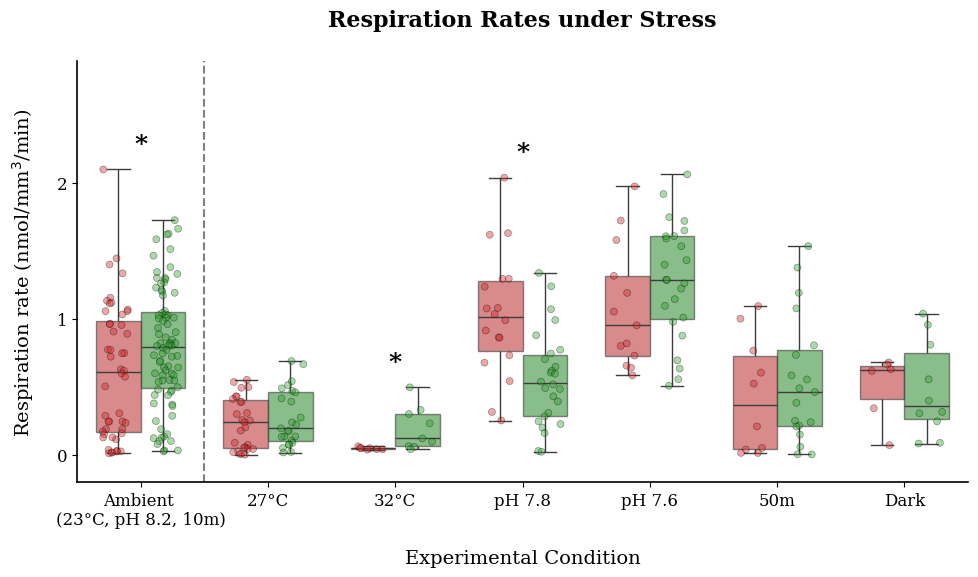

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ==========================================
# BLOCK 5: MASTER RESPIRATION PLOT
# ==========================================

fig, ax = plt.subplots(figsize=global_fig_size)

sns.boxplot(
    data=respiration_clean,
    x='Treatment',
    y='oxy_rate',
    hue='morph',
    order=plot_order,
    palette=variant_colors,
    ax=ax,
    width=0.7,
    boxprops=dict(alpha=global_alpha),
    showfliers=False,
)

sns.stripplot(
    data=respiration_clean,
    x='Treatment',
    y='oxy_rate',
    hue='morph',
    order=plot_order,
    palette=variant_colors,
    ax=ax,
    dodge=True,
    size=global_marker_size,
    alpha=0.4,
    jitter=global_jitter,
    edgecolor='black',
    linewidth=0.5,
)

# Main title remains bold; axis titles are standard weight per request
ax.set_title("Respiration Rates under Stress", fontweight='bold', pad=25)
ax.set_xlabel("Experimental Condition", labelpad=15)
ax.set_ylabel(r"Respiration rate (nmol/mm$^3$/min)", labelpad=15)

# Adjust Y-axis ticks to every 1 unit
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5)
ax.set_ylim(respiration_clean['oxy_rate'].min() - 0.2, respiration_clean['oxy_rate'].max() + 0.8)

# Add significant asterisks using Global Infrastructure settings
if 'oxy_results_df' in globals():
    sig_results = oxy_results_df[oxy_results_df['Significant'] == True]
    for idx, row in sig_results.iterrows():
        condition = row['Condition']
        if condition in plot_order:
            x_pos = plot_order.index(condition)
            max_y = respiration_clean[respiration_clean['Treatment'] == condition]['oxy_rate'].max()
            ax.text(x_pos, max_y + 0.1, '*', ha='center', va='bottom',
                    fontsize=global_asterisk_size, color='black',
                    fontweight=global_asterisk_weight)

# Explicitly remove legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

sns.despine()
plt.tight_layout()

# Save the figure as 600 DPI SVG
plt.savefig("respiration_plot_600dpi.svg", format='svg', dpi=600, bbox_inches='tight')

plt.show()